# The Kelly Criterion in a Real Portfolio
### Why half a "perfect" bet beats the perfect bet

This notebook is the executable version of my capstone, *Maximizing Long-Term
Investment Growth: A Study of the Kelly Criterion's Portfolio Applications*.

The Kelly Criterion answers one question: **what fraction of your capital should
you risk on a favorable bet to maximize long-run growth?** Applied to a portfolio
of ETFs, it produces target weights from two inputs: expected excess returns and
the covariance of returns.

The catch — and the central finding of the capstone — is that those inputs are
*estimated*, and Kelly is brutally sensitive to estimation error. Betting more
than the true Kelly fraction doesn't just add volatility; past 2× Kelly it
destroys growth entirely. That asymmetry is why practitioners bet **fractional
Kelly**: half or a quarter of the formula's suggestion.

## The math in plain words

For a single asset, the Kelly weight has a closed form:

$$w^* = \frac{\mu - r}{\sigma^2}$$

where $\mu$ is the expected return, $r$ the risk-free rate, and $\sigma^2$ the
variance. For multiple assets it generalizes to $w^* = \Sigma^{-1}(\mu - r)$.

Long-run growth as a function of your bet size is a downward parabola centered
at $w^*$: betting half Kelly gives you **75% of the maximum growth with half the
volatility**, while betting double Kelly gives you **zero** long-run growth.
Under-betting costs a little; over-betting is fatal. Since $\mu$ is the noisiest
estimate in finance, the rational response to uncertainty is to scale down.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import yaml

from kellyfolio.data import get_prices

config = yaml.safe_load(open("../config.yaml"))
config["cache"] = "../data/prices.csv"
prices = get_prices(config["tickers"], config["start_date"], cache_path=config["cache"])
prices.tail(3)

Ticker,GLD,SPY,TLT
Date,,,
2026-06-08,397.269989,739.219971,84.620003
2026-06-09,390.779999,737.049988,85.120003
2026-06-10,374.579987,725.429993,84.879997


## Today's Kelly weights — and why you shouldn't trust them too much

Below: the portfolio the formula suggests today, at full, half, and quarter
Kelly. Then the "own the flaws" experiment — we nudge the expected return of
each asset by just ±2 percentage points (well within estimation noise) and watch
how violently the weights react. This sensitivity is the practical argument for
fractional Kelly.

In [2]:
from kellyfolio.estimate import estimate_mu_sigma
from kellyfolio.kelly import kelly_weights

mu, sigma = estimate_mu_sigma(prices, config["lookback_months"])

weights = pd.DataFrame({
    f"{frac:.2f} Kelly": kelly_weights(mu, sigma, config["risk_free_rate"], frac)
    for frac in (1.0, 0.5, 0.25)
})
print("Annualized expected returns (mu):")
print(mu.round(3).to_string())
weights.round(3)

Annualized expected returns (mu):
Ticker
GLD    0.152
SPY    0.124
TLT   -0.063


,1.00 Kelly,0.50 Kelly,0.25 Kelly
Ticker,,,
GLD,0.578,0.289,0.145
SPY,0.422,0.211,0.105
TLT,0.000,0.000,0.000


In [3]:
# Estimation-error experiment: same covariance, mu shifted by +/- 2 points.
shock = 0.02
sensitivity = pd.DataFrame({
    "mu as estimated": kelly_weights(mu, sigma, config["risk_free_rate"], 1.0),
    "mu + 2pts (all)": kelly_weights(mu + shock, sigma, config["risk_free_rate"], 1.0),
    "mu - 2pts (all)": kelly_weights(mu - shock, sigma, config["risk_free_rate"], 1.0),
})
sensitivity.round(3)

,mu as estimated,mu + 2pts (all),mu - 2pts (all)
Ticker,,,
GLD,0.578,0.559,0.604
SPY,0.422,0.441,0.396
TLT,0.000,0.000,0.000


## Walk-forward backtest — no cheating

Every month-end, the strategy estimates $\mu$ and $\Sigma$ **using only data
available up to that date**, sets weights, holds them a month, and pays 0.1% on
turnover. The first five years are warm-up (the lookback window), so all curves
are aligned to the common start date for a fair comparison.

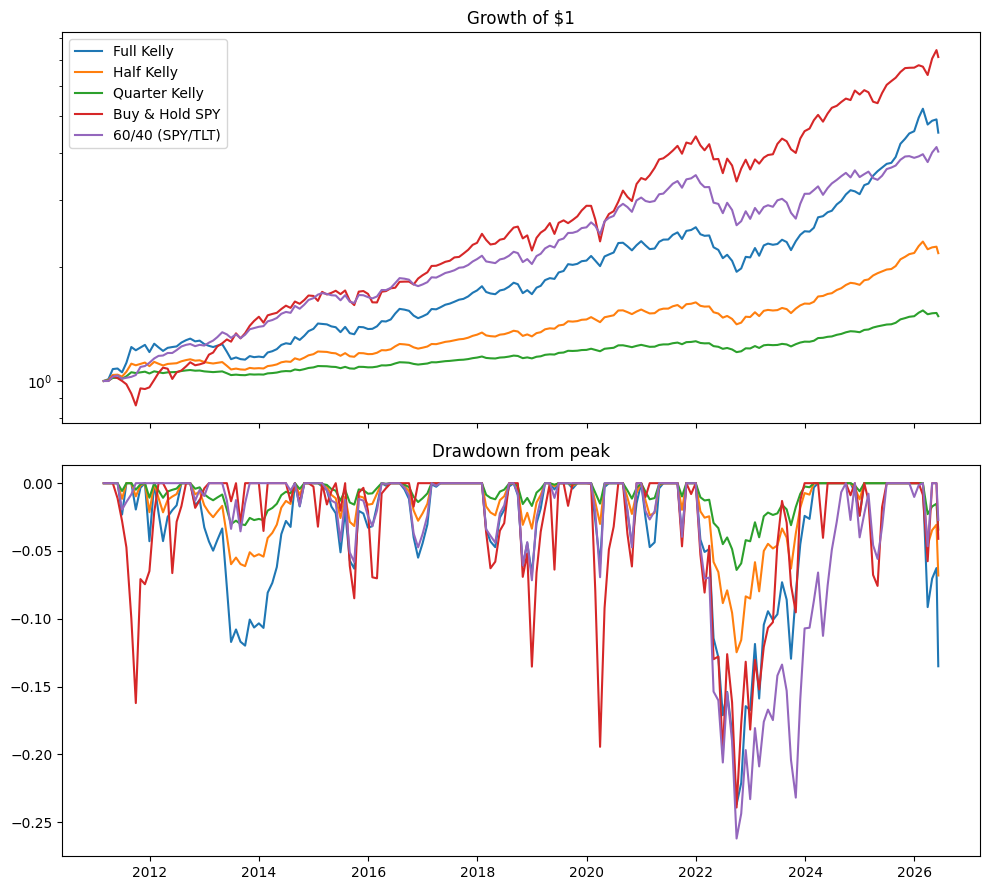

In [4]:
import matplotlib.pyplot as plt

from kellyfolio.backtest import run_backtest, fixed_weights, cagr, max_drawdown, sharpe
from kellyfolio.report import kelly_strategy

strategies = {
    "Full Kelly": kelly_strategy({**config, "kelly_fraction": 1.0}),
    "Half Kelly": kelly_strategy({**config, "kelly_fraction": 0.5}),
    "Quarter Kelly": kelly_strategy({**config, "kelly_fraction": 0.25}),
    "Buy & Hold SPY": fixed_weights(pd.Series({"SPY": 1.0})),
    "60/40 (SPY/TLT)": fixed_weights(pd.Series({"SPY": 0.6, "TLT": 0.4})),
}
results = {n: run_backtest(prices, fn, config["transaction_cost"]) for n, fn in strategies.items()}

common_start = max(r.equity.index[0] for r in results.values())
curves = {n: (e := r.equity.loc[common_start:]) / e.iloc[0] for n, r in results.items()}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
for name, c in curves.items():
    ax1.plot(c, label=name)
    ax2.plot(c / c.cummax() - 1, label=name)
ax1.set_yscale("log"); ax1.set_title("Growth of $1"); ax1.legend()
ax2.set_title("Drawdown from peak")
plt.tight_layout(); plt.show()

In [5]:
metrics = pd.DataFrame({
    name: {"CAGR": cagr(c), "Max Drawdown": max_drawdown(c),
           "Sharpe": sharpe(c, config["risk_free_rate"])}
    for name, c in curves.items()
}).T
metrics.style.format({"CAGR": "{:.1%}", "Max Drawdown": "{:.1%}", "Sharpe": "{:.2f}"})

,CAGR,Max Drawdown,Sharpe
Full Kelly,10.4%,-23.7%,0.81
Half Kelly,5.2%,-12.5%,0.61
Quarter Kelly,2.6%,-6.4%,0.23
Buy & Hold SPY,13.7%,-23.9%,0.83
60/40 (SPY/TLT),9.5%,-26.2%,0.76


## Honest limitations

1. **Estimation error dominates.** Historical means are a weak forecast of
   future returns — the sensitivity table above shows the weights swinging on a
   2-point nudge. Shrinkage estimators (Ledoit–Wolf) are the natural next step.
2. **Regime dependence.** The aligned test window (2011–present) is mostly a
   historic US equity bull market, which is exactly when 100% SPY looks
   unbeatable on raw CAGR. The Kelly portfolios still match or beat it on
   drawdown and (at full fraction) on Sharpe.
3. **Costs and taxes.** A flat 0.1% turnover cost is modeled; taxes and bid-ask
   spreads are not.
4. **Universe chosen with hindsight.** SPY/TLT/GLD is a sensible, liquid
   universe — but it was chosen knowing these assets survived and prospered.

## Conclusion & roadmap

Constrained (no-leverage) Kelly with a fraction dial does what the theory
promises: the fraction directly trades growth for drawdown protection, and full
Kelly beats a 60/40 benchmark on growth, drawdown, and Sharpe in the test
window. For my own account the practical configuration is **half Kelly** —
documented in `config.yaml` and printed monthly by `python -m kellyfolio report`.

- **Phase 2:** Streamlit dashboard demo.
- **Phase 3:** Alpaca paper trading; real money only after the demo proves out.